# W1D4 — Evaluating Honestly — Lab

**Week 1 · Day 4 · Foundations** · Lab

Today you build a model that looks respectable, and then you take it apart. Its accuracy is 0.81. A
model that predicts "nobody ever defaults" — one line of code, no learning of any kind — scores 0.78 on
the same data. Three points. The whole lab is about what those three points are actually made of, and
about the four numbers that would have told you straight away. You will count a confusion matrix by
hand, compute precision and recall by hand, sweep the threshold from 0.05 to 0.95, and then answer a
question that has no correct answer: the bank can review 200 applications a month. Which threshold do
you recommend, and what does it cost?

You leave with `threshold_sweep.parquet`.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٤ — التقييم الأمين

**الأسبوع ١ · اليوم ٤ · الأساسيات** · معمل عملي

اليوم تبني نموذجًا يبدو محترمًا ثم تفكّكه. دقّته ٠٫٨١. ونموذج يتنبّأ بأن «لا أحد يتعثّر أبدًا» — سطر واحد
بلا أي تعلّم — يسجّل ٠٫٧٨ على البيانات نفسها. ثلاث نقاط. والمعمل كلّه عمّا تتكوّن منه هذه النقاط الثلاث
فعلًا، وعن الأرقام الأربعة التي كانت ستخبرك فورًا. ستَعُدّ مصفوفة الالتباس يدويًا، وتحسب الدقة (Precision)
والاستدعاء (Recall) يدويًا، وتمسح العتبة من ٠٫٠٥ إلى ٠٫٩٥، ثم تجيب عن سؤال بلا إجابة صحيحة: يستطيع البنك
مراجعة ٢٠٠ طلب شهريًا. أي عتبة توصي بها، وما ثمنها؟

وستخرج بملف `threshold_sweep.parquet`.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Build a confusion matrix by hand and say which cell `confusion_matrix` puts where.
- Compute precision, recall and F1 from the four counts, without `classification_report`.
- Show that accuracy on an imbalanced problem can be beaten by a model that has learned nothing.
- Sweep a decision threshold and read the precision/recall trade-off off the plot.
- Recommend a threshold for a stated operational limit, and name what it costs.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- بناء مصفوفة الالتباس يدويًا وتحديد موضع كل خانة في مخرج `confusion_matrix`.
- حساب الدقة والاستدعاء وF1 من الأعداد الأربعة دون `classification_report`.
- إثبات أن الدقّة الكلّية في مسألة غير متوازنة يمكن أن يتفوّق عليها نموذج لم يتعلّم شيئًا.
- مسح عتبة القرار وقراءة المفاضلة بين الدقة والاستدعاء من الرسم.
- التوصية بعتبة تناسب حدًّا تشغيليًا معلومًا، وتسمية ثمنها.

</div>

## About the data

**Dataset:** `credit_default` — UCI *Default of Credit Card Clients* (Taiwan, 2005) · CC BY 4.0 ·
30,000 rows

One row is one credit-card client. The target, `default_next_month`, is 1 if they missed the next
month's payment. **22.1% of them did**, and that imbalance is the reason this dataset is here rather
than a tidier one: at 22% positive, accuracy is not theoretically misleading, it is actively misleading,
and you will see it happen in Task 2.2.

Today you use three columns only: `LIMIT_BAL` (the credit limit), `AGE`, and `PAY_0` (the repayment
status of the most recent month). That restriction is deliberate. A model with all 23 columns is good
enough that the lesson disappears; this one is good enough to be tempting and bad enough to be honest.

**Watch out:** `PAY_0` through `PAY_6` use an undocumented coding in which **−2, −1 and 0 all mean "not
late"**, and positive values are months of delay. Nobody published the difference between the three
non-late codes. You are using the column anyway, as everyone who has ever used this dataset does — but
now you know that one of your three features has a definition nobody can give you. Say so out loud if
anyone asks what the model is based on.

There is a second oddity: the columns run `PAY_0`, then `PAY_2` to `PAY_6`. There is no `PAY_1`. That
is how UCI published it, and the builder that produced this file deliberately did not tidy it.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `credit_default` — تعثّر عملاء بطاقات الائتمان من UCI (تايوان، ٢٠٠٥) · رخصة
CC BY 4.0 · ٣٠٬٠٠٠ صف

الصف الواحد عميل بطاقة ائتمانية واحد. والهدف `default_next_month` يساوي واحدًا إذا تخلّف عن سداد الشهر
التالي. وقد تخلّف **٢٢٫١٪** منهم، وهذا الاختلال هو سبب وجود هذه المجموعة هنا بدل مجموعة أنظف: فعند نسبة
٢٢٪ لا تكون الدقّة الكلّية مضلّلة نظريًا بل مضلّلة فعليًا، وسترى ذلك يحدث في المهمة ٢٫٢.

اليوم تستخدم ثلاثة أعمدة فقط: `LIMIT_BAL` (حدّ الائتمان) و`AGE` و`PAY_0` (حالة السداد في آخر شهر).
وهذا التقييد مقصود. فالنموذج بكل الأعمدة الثلاثة والعشرين جيّد بما يُفقد الدرس معناه؛ وهذا النموذج جيّد
بما يُغري وسيّئ بما يُبقيه أمينًا.

**انتبه:** الأعمدة من `PAY_0` إلى `PAY_6` تستخدم ترميزًا غير موثّق تعني فيه القيم **‎−٢ و‎−١ و٠ جميعها
«غير متأخّر»**، والقيم الموجبة عدد أشهر التأخير. ولم يَنشر أحد الفرق بين الرموز الثلاثة غير المتأخّرة.
وأنت تستخدم العمود على أي حال، كما فعل كل من استخدم هذه البيانات — لكنك الآن تعلم أن إحدى خصائصك الثلاث
لها تعريف لا يستطيع أحد أن يعطيك إياه. قُل ذلك صراحةً إن سُئلت عمّا يقوم عليه النموذج.

وثمّة غرابة ثانية: الأعمدة `PAY_0` ثم من `PAY_2` إلى `PAY_6`. ولا وجود لـ`PAY_1`. هكذا نشرتها UCI،
والأداة التي بنت هذا الملف تعمّدت ألّا ترتّبها.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and finds the dataset —
whether you are on your own machine or on Google Colab.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات — سواء كنت على
جهازك أو على Google Colab.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_close, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("credit_default")
credit = pd.read_parquet(DATA)

TARGET = "default_next_month"
FEATURES = ["LIMIT_BAL", "AGE", "PAY_0"]     # deliberately restricted — see "About the data"

print(describe_dataset("credit_default"))
print(f"\n{credit.shape[0]:,} clients | default rate {credit[TARGET].mean():.4f}")
print("\n", versions())

⬇️  Downloading credit_default.parquet (1.75 MB) …
✅ credit_default: downloaded to /content/aiep_data/credit_default.parquet
credit_default  (30000 rows, 1.75 MB)
  Source:  UCI Default of Credit Card Clients
  Licence: CC BY 4.0
  Target:  default_next_month

  EN: Credit-card clients with a default flag. Used for evaluation under class imbalance (W1D4) and for trees and ensembles (W3D1), where feature importance has a meaning students can argue about.
  AR: عملاء بطاقات ائتمانية مع مؤشّر التعثّر. تُستخدم في التقييم مع اختلال توازن الفئات (الأسبوع ١ اليوم ٤) وفي النماذج الشجرية (الأسبوع ٣ اليوم ١) حيث تحمل أهمية الخصائص معنى يستحق النقاش.

  ⚠️  Watch out: PAY_0..PAY_6 use an undocumented coding where -2, -1 and 0 all mean 'not late'.
  ⚠️  انتبه: الأعمدة PAY_0 إلى PAY_6 تستخدم ترميزًا غير موثّق تعني فيه القيم -2 و-1 و0 جميعها «غير متأخّر».

30,000 clients | default rate 0.2212

 python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | torch 2.11.0+cpu | transformers 5.16.1


## Section 1 — Warm-up: count the four cells yourself  (≈25 min)

Guided. The code below works. Run it, read it, then do the counting the task asks for.

These are the same ten predictions from this morning, sorted by confidence. Cut at 0.5, so rows 1 to 5
are predicted positive and rows 6 to 10 negative.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: عُدّ الخانات الأربع بنفسك (نحو ٢٥ دقيقة)

قسم موجَّه. الشيفرة أدناه تعمل. شغّلها واقرأها، ثم نفّذ العدّ الذي تطلبه المهمة.

هذه هي التنبّؤات العشرة نفسها من هذا الصباح، مرتّبة بحسب الثقة. القطع عند ٠٫٥، فالصفوف من ١ إلى ٥
مُتنبَّأ لها بالإيجاب ومن ٦ إلى ١٠ بالسلب.

</div>

In [2]:
# Working code. Nothing to fill in here.
lecture_probs = np.array([0.95, 0.80, 0.72, 0.61, 0.55, 0.48, 0.40, 0.30, 0.18, 0.09])
lecture_true  = np.array([1,    0,    1,    0,    0,    0,    0,    0,    0,    0])
lecture_pred  = (lecture_probs >= 0.5).astype(int)

print(pd.DataFrame({
    "row": np.arange(1, 11),
    "prob": lecture_probs,
    "predicted": lecture_pred,
    "true": lecture_true,
}).to_string(index=False))

 row  prob  predicted  true
   1  0.95          1     1
   2  0.80          1     0
   3  0.72          1     1
   4  0.61          1     0
   5  0.55          1     0
   6  0.48          0     0
   7  0.40          0     0
   8  0.30          0     0
   9  0.18          0     0
  10  0.09          0     0


### Task 1.1 — count them into a dictionary

Go along the ten rows and count the four possible outcomes into `hand_counts`. Then check yourself
against `confusion_matrix`.

Two of the four are easy to mix up, so be careful about which is which: a **false positive** is
something you flagged that was fine, and a **false negative** is something you let through that was
not.

<div dir="rtl" align="right">

### المهمة ١٫١ — عُدّها في قاموس

مُرّ على الصفوف العشرة وعُدّ النتائج الأربع الممكنة في `hand_counts`. ثم تحقّق من نفسك بـ`confusion_matrix`.

اثنتان من الأربع يسهل الخلط بينهما، فانتبه أيّهما أيّ: **الإيجابية الكاذبة** شيء علّمته وكان سليمًا،
و**السلبية الكاذبة** شيء تركته يمرّ ولم يكن سليمًا.

</div>

In [4]:
import numpy as np

# ────────────────────────────────────────────────────────────────────
# 1) Four counts: predicted 1 and true 1, predicted 1 and true 0, predicted 0 and true 1,
#    predicted 0 and true 0. Count each by comparing the two arrays.
# 2) Fill the dictionary below with keys "tp", "fp", "fn", "tn".
# 3) They must add up to 10. If they do not, you have double-counted a row.
# Search: "numpy count where two conditions both true"
#
# ١) أربعة أعداد: تنبّؤ ١ وحقيقة ١، وتنبّؤ ١ وحقيقة ٠، وتنبّؤ ٠ وحقيقة ١، وتنبّؤ ٠ وحقيقة ٠.
#    عُدّ كلًّا منها بمقارنة المصفوفتين.
# ٢) املأ القاموس أدناه بالمفاتيح "tp" و"fp" و"fn" و"tn".
# ٣) يجب أن يكون مجموعها عشرة. فإن لم يكن فقد عددت صفًا مرتين.
# ابحث عن: "numpy count where two conditions both true"
# ────────────────────────────────────────────────────────────────────

# TODO: Count the four outcomes of the ten rows into hand_counts, by hand — no sklearn here.
# مهمة: عُدّ النتائج الأربع للصفوف العشرة في hand_counts يدويًا — بلا sklearn هنا.

tp = np.sum((lecture_pred == 1) & (lecture_true == 1))
fp = np.sum((lecture_pred == 1) & (lecture_true == 0))
fn = np.sum((lecture_pred == 0) & (lecture_true == 1))
tn = np.sum((lecture_pred == 0) & (lecture_true == 0))

hand_counts = {
    "tp": tp,
    "fp": fp,
    "fn": fn,
    "tn": tn
}

print(hand_counts, "-> total", sum(hand_counts.values()))

{'tp': np.int64(2), 'fp': np.int64(3), 'fn': np.int64(0), 'tn': np.int64(5)} -> total 10


In [5]:
# Working code. Nothing to fill in here — but read the layout carefully.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(lecture_true, lecture_pred)
print(cm)
print()
print(pd.DataFrame(cm,
                   index=["true 0", "true 1"],
                   columns=["predicted 0", "predicted 1"]).to_string())

tn, fp, fn, tp = cm.ravel()
print(f"\nsklearn unpacks as: tn={tn} fp={fp} fn={fn} tp={tp}")
print(f"you counted        : tn={hand_counts['tn']} fp={hand_counts['fp']} "
      f"fn={hand_counts['fn']} tp={hand_counts['tp']}")
print(f"\naccuracy = (tp + tn) / 10 = ({tp} + {tn}) / 10 = {(tp + tn) / 10:.2f}")

[[5 3]
 [0 2]]

        predicted 0  predicted 1
true 0            5            3
true 1            0            2

sklearn unpacks as: tn=5 fp=3 fn=0 tp=2
you counted        : tn=5 fp=3 fn=0 tp=2

accuracy = (tp + tn) / 10 = (2 + 5) / 10 = 0.70


Note the layout, because it catches people every single time. `confusion_matrix` returns rows as the
**truth** and columns as the **prediction**, so `ravel()` gives you `tn, fp, fn, tp` — true negative
first, true positive last. That is not the order anyone says them in. Check it every time, on every
project; do not assume.

Accuracy on these ten rows is 0.70, exactly as on the slide. Hold on to that number for two minutes,
because it is about to stop meaning anything.

<div dir="rtl" align="right">

انتبه إلى الترتيب، فهو يُوقع الناس في كل مرة. تُرجع `confusion_matrix` الصفوف بوصفها **الحقيقة**
والأعمدة بوصفها **التنبّؤ**، فيعطيك `ravel()` الترتيب `tn, fp, fn, tp` — السلبية الصحيحة أولًا والإيجابية
الصحيحة آخرًا. وليس هذا الترتيب الذي ينطق به أحد. تحقّق منه في كل مرة وفي كل مشروع، ولا تفترض.

الدقّة على هذه الصفوف العشرة ٠٫٧٠ تمامًا كما في الشريحة. احتفظ بهذا الرقم دقيقتين، فهو على وشك أن يتوقّف
عن الدلالة على شيء.

</div>

## Section 2 — Core: the number that lies, and the four that do not  (≈60 min)

This is the lab. Each task below has a goal; you write the code.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: الرقم الذي يكذب والأربعة التي لا تكذب (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة أدناه هدف محدّد، وأنت من يكتب الشيفرة.

</div>

### Task 2.1 — fit a model and report its accuracy

Split 80/20 stratified on the target, fit `LogisticRegression` on the three features, and report the
accuracy on the test set.

Write the number down before you go on to the next task.

<div dir="rtl" align="right">

### المهمة ٢٫١ — درّب نموذجًا واذكر دقّته

قسّم ٨٠٪ / ٢٠٪ تقسيمًا طبقيًا على الهدف، ودرّب `LogisticRegression` على الخصائص الثلاث، واذكر الدقّة على
مجموعة الاختبار.

اكتب الرقم قبل أن تنتقل إلى المهمة التالية.

</div>

In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) X is the three FEATURES columns as a float array; y is the TARGET column.
# 2) Split 20% out, stratified on y, random_state=42 — the same recipe as yesterday.
# 3) Fit a logistic regression. It needs more iterations than the default here because the
#    credit limits run into the hundreds of thousands; pass max_iter=2000.
# 4) Store the test-set probabilities in `probs` — every later task uses them.
# Search: "sklearn LogisticRegression max_iter accuracy_score"
#
# ١) المصفوفة X هي أعمدة FEATURES الثلاثة كأرقام عشرية، وy هو عمود TARGET.
# ٢) اعزل ٢٠٪ للاختبار تقسيمًا طبقيًا على y مع random_state=42 — الوصفة نفسها كالأمس.
# ٣) درّب انحدارًا لوجستيًا. يحتاج تكرارات أكثر من الافتراضي هنا لأن حدود الائتمان تبلغ مئات
#    الآلاف؛ مرّر max_iter=2000.
# ٤) خزّن احتمالات مجموعة الاختبار في `probs` — فكل مهمة تالية تستخدمها.
# ابحث عن: "sklearn LogisticRegression max_iter accuracy_score"
# ────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X = credit[FEATURES].to_numpy(dtype=float)
y = credit[TARGET].to_numpy()
# TODO: Split 80/20 stratified on y, fit LogisticRegression, and put P(default) for the test set in `probs`.
# مهمة: قسّم ٨٠٪ / ٢٠٪ طبقيًا على y، ودرّب LogisticRegression، وضع احتمال التعثّر لمجموعة الاختبار في `probs`.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

model_accuracy = accuracy_score(y_test, probs >= 0.5)
print(f"test set: {len(y_test):,} clients, {int(y_test.sum()):,} of whom defaulted "
      f"({y_test.mean():.4f})")
print(f"model accuracy at threshold 0.5: {model_accuracy:.4f}")

test set: 6,000 clients, 1,327 of whom defaulted (0.2212)
model accuracy at threshold 0.5: 0.8103


### Task 2.2 — beat it with a model that has learned nothing

`DummyClassifier(strategy="most_frequent")` fits nothing. It looks at the training labels, notices that
"no default" is more common, and predicts that for every client forever.

Compute its accuracy on the same test set. Then compute how many defaulters each of the two models
catches.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — تفوَّق عليه بنموذج لم يتعلّم شيئًا

الأداة `DummyClassifier(strategy="most_frequent")` لا تدرّب شيئًا. تنظر إلى تسميات التدريب، وتلاحظ أن
«لا تعثّر» أكثر شيوعًا، فتتنبّأ بها لكل عميل إلى الأبد.

احسب دقّتها على مجموعة الاختبار نفسها. ثم احسب كم متعثّرًا يمسك كل من النموذجين.

</div>

In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) Fit DummyClassifier(strategy="most_frequent") on the training data and score it on test.
# 2) Print both accuracies and the gap between them, in points.
# 3) Then count, for each model, how many of the real defaulters it flagged. That is the
#    number accuracy is hiding from you.
# Search: "sklearn DummyClassifier most_frequent baseline"
# https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
#
# ١) درّب DummyClassifier(strategy="most_frequent") على بيانات التدريب وقيّمه على الاختبار.
# ٢) اطبع الدقّتين والفارق بينهما بالنقاط.
# ٣) ثم عُدّ لكل نموذج كم متعثّرًا حقيقيًا علّمه. هذا هو الرقم الذي تخفيه عنك
#    الدقّة الكلّية.
# ابحث عن: "sklearn DummyClassifier most_frequent baseline"
# ────────────────────────────────────────────────────────────────────

from sklearn.dummy import DummyClassifier
# TODO: Score DummyClassifier against your model, then count the defaulters each of them catches.
# مهمة: قيّم DummyClassifier مقابل نموذجك، ثم عُدّ المتعثّرين الذين يمسكهم كل منهما.

dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)
dummy_accuracy = accuracy_score(y_test, dummy_pred)

caught_by_model = np.sum((y_test == 1) & (probs >= 0.5))
caught_by_dummy = np.sum((y_test == 1) & (dummy_pred == 1))

print(f"your model : accuracy {model_accuracy:.4f}")
print(f"dummy      : accuracy {dummy_accuracy:.4f}")
print(f"difference : {model_accuracy - dummy_accuracy:+.4f} "
      f"({(model_accuracy - dummy_accuracy) * 100:.1f} points)\n")
print(f"defaulters in the test set : {int(y_test.sum()):,}")
print(f"caught by your model       : {caught_by_model:,} "
      f"({caught_by_model / y_test.sum():.1%})")
print(f"caught by the dummy        : {caught_by_dummy:,}")

your model : accuracy 0.8103
dummy      : accuracy 0.7788
difference : +0.0315 (3.1 points)

defaulters in the test set : 1,327
caught by your model       : 342 (25.8%)
caught by the dummy        : 0


This is the moment of the lab. Read it slowly.

Your model is three points better than a model that cannot learn — and it is three points better on a
metric that rewards it for agreeing with the dummy on the 78% of clients who never default. On the
1,327 clients the bank actually cares about, the dummy catches **zero** and your model catches about a
quarter.

Accuracy cannot see that difference, because it is dominated by the majority class. The dummy is not a
strawman: on an imbalanced problem it is a genuinely hard baseline to beat by much, and any report that
quotes accuracy without quoting it next to the dummy's is not a report, it is a decoration.

From here on, accuracy is not mentioned again.

<div dir="rtl" align="right">

هذه هي لحظة المعمل. اقرأها على مهل.

نموذجك أفضل بثلاث نقاط من نموذج لا يستطيع التعلّم — وهو أفضل بثلاث نقاط في مقياس يكافئه على موافقة
النموذج الساذج في الـ٧٨٪ من العملاء الذين لا يتعثّرون أصلًا. أما على الـ١٬٣٢٧ عميلًا الذين يهمّون البنك
فعلًا، فالنموذج الساذج يمسك **صفرًا** ونموذجك يمسك نحو الربع.

والدقّة الكلّية لا ترى هذا الفرق لأن الفئة الأكثر تهيمن عليها. والنموذج الساذج ليس خصمًا وهميًا: ففي
المسائل غير المتوازنة يصعب التفوّق عليه بفارق كبير، وأي تقرير يذكر الدقّة دون أن يذكر دقّة النموذج الساذج
بجوارها ليس تقريرًا بل زينة.

ومن هنا فصاعدًا لن تُذكر الدقّة مرة أخرى.

</div>

### Task 2.3 — precision, recall and F1, by hand

Build the confusion matrix for your model at threshold 0.5, pull out the four counts, and compute
precision, recall and F1 **from the counts** — not from `classification_report`. Then print
`classification_report` and check that your three numbers appear in it.

Doing it by hand once is the difference between knowing the formula and knowing what it measures.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الدقة والاستدعاء وF1 يدويًا

ابنِ مصفوفة الالتباس لنموذجك عند العتبة ٠٫٥، واستخرج الأعداد الأربعة، واحسب الدقة والاستدعاء وF1 **من
الأعداد** لا من `classification_report`. ثم اطبع `classification_report` وتحقّق أن أرقامك الثلاثة فيه.

وحسابها يدويًا مرة واحدة هو الفرق بين معرفة الصيغة ومعرفة ما تقيسه.

</div>

In [11]:
# ────────────────────────────────────────────────────────────────────
# 1) confusion_matrix on the test labels and your 0.5 predictions, then ravel() it.
#    Remember the order it gives you back — you checked it in Task 1.1.
# 2) Precision: of everything you flagged, what share was real. Recall: of everything that
#    was real, what share you caught. Neither uses the true negatives.
# 3) F1 is the harmonic mean: 2 * precision * recall / (precision + recall).
# 4) Then print classification_report with digits=4 and find your numbers in the row for
#    class 1. If they differ, your formula is wrong, not sklearn's.
# Search: "precision recall f1 formula from confusion matrix"
#
# ١) استدعِ confusion_matrix على تسميات الاختبار وتنبّؤات ٠٫٥ لديك، ثم فكّكها بـravel().
#    وتذكّر الترتيب الذي تُرجعه — فقد تحقّقت منه في المهمة ١٫١.
# ٢) الدقة: من كل ما علّمته، ما نسبة الصحيح. والاستدعاء: من كل ما كان صحيحًا، ما نسبة ما
#    أمسكته. ولا تستخدم أيّ منهما السلبيات الصحيحة.
# ٣) وF1 هو المتوسّط التوافقي: 2 * precision * recall / (precision + recall).
# ٤) ثم اطبع classification_report بـdigits=4 وابحث عن أرقامك في صف الفئة ١. فإن اختلفت
#    فالخطأ في صيغتك لا في sklearn.
# ابحث عن: "precision recall f1 formula from confusion matrix"
# ────────────────────────────────────────────────────────────────────

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
# TODO: Get tn, fp, fn, tp for your model at 0.5, then compute precision, recall and f1 from them.
# مهمة: استخرج tn وfp وfn وtp لنموذجك عند ٠٫٥، ثم احسب منها الدقة والاستدعاء وF1.

y_pred_05 = probs >= 0.5
cm_model = confusion_matrix(y_test, y_pred_05)
m_tn, m_fp, m_fn, m_tp = cm_model.ravel()

precision = m_tp / (m_tp + m_fp) if (m_tp + m_fp) > 0 else 0.0
recall = m_tp / (m_tp + m_fn) if (m_tp + m_fn) > 0 else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"tn={m_tn}  fp={m_fp}  fn={m_fn}  tp={m_tp}\n")
print(f"precision = {m_tp} / ({m_tp} + {m_fp}) = {precision:.4f}")
print(f"recall    = {m_tp} / ({m_tp} + {m_fn}) = {recall:.4f}")
print(f"f1        = {f1:.4f}\n")
print(classification_report(y_test, probs >= 0.5, digits=4,
                            target_names=["no default", "default"]))

tn=4520  fp=153  fn=985  tp=342

precision = 342 / (342 + 153) = 0.6909
recall    = 342 / (342 + 985) = 0.2577
f1        = 0.3754

              precision    recall  f1-score   support

  no default     0.8211    0.9673    0.8882      4673
     default     0.6909    0.2577    0.3754      1327

    accuracy                         0.8103      6000
   macro avg     0.7560    0.6125    0.6318      6000
weighted avg     0.7923    0.8103    0.7748      6000



Say what those two numbers mean in words, because the words are the skill.

Precision 0.69: of the clients you flagged, roughly seven in ten really did default. Recall 0.26: of the
clients who really did default, you flagged roughly one in four. **You missed 985 of them.** Accuracy
0.81 said none of that.

And notice which cell neither metric uses: `tn`, the 4,520 clients you correctly left alone. That
omission is exactly why precision and recall survive imbalance. Accuracy is mostly a measurement of
`tn` here, and `tn` is the easy part.

<div dir="rtl" align="right">

قُل ما يعنيه هذان الرقمان بالكلمات، فالكلمات هي المهارة.

الدقة ٠٫٦٩: من العملاء الذين علّمتهم، نحو سبعة من كل عشرة تعثّروا فعلًا. والاستدعاء ٠٫٢٦: من العملاء
الذين تعثّروا فعلًا، علّمت نحو واحد من كل أربعة. **وفاتك ٩٨٥ منهم.** ولم تقل الدقّة ٠٫٨١ شيئًا من ذلك.

ولاحظ الخانة التي لا يستخدمها أيّ من المقياسين: `tn`، أي الـ٤٬٥٢٠ عميلًا الذين تركتهم بحق. وهذا الإسقاط
بعينه هو سبب صمود الدقة والاستدعاء أمام الاختلال. فالدقّة الكلّية هنا قياس لـ`tn` في معظمها، و`tn` هو
الجزء السهل.

</div>

### Task 2.4 — sweep the threshold

0.5 was never a decision. Compute precision, recall and the number of clients flagged at every threshold
from 0.05 to 0.95 in steps of 0.05, and collect them into a DataFrame called `sweep`.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — امسح العتبة

لم تكن ٠٫٥ قرارًا قط. احسب الدقة والاستدعاء وعدد العملاء المعلَّمين عند كل عتبة من ٠٫٠٥ إلى ٠٫٩٥ بخطوة
٠٫٠٥، واجمعها في DataFrame باسم `sweep`.

</div>

In [13]:
# ────────────────────────────────────────────────────────────────────
# 1) np.arange(0.05, 0.96, 0.05) gives you the thresholds. Round them — floating point
#    arithmetic will hand you 0.30000000000000004 otherwise.
# 2) At each one, flag the rows at or above it and recompute the same three counts you used
#    in Task 2.3. You do not need confusion_matrix for this; the boolean arrays are enough.
# 3) Collect one dict per threshold with keys: threshold, precision, recall, n_flagged.
# 4) Build the DataFrame at the end and print it whole. Nineteen rows fits on a screen.
# Search: "numpy arange loop threshold precision recall"
#
# ١) تعطيك np.arange(0.05, 0.96, 0.05) العتبات. قرّبها، وإلا سلّمك حساب الفاصلة العائمة
#    القيمة 0.30000000000000004.
# ٢) عند كل عتبة، علّم الصفوف عندها أو فوقها وأعد حساب الأعداد الثلاثة نفسها من المهمة ٢٫٣.
#    ولا تحتاج confusion_matrix هنا؛ فالمصفوفات المنطقية تكفي.
# ٣) اجمع قاموسًا لكل عتبة بالمفاتيح: threshold وprecision وrecall وn_flagged.
# ٤) ابنِ الـDataFrame في النهاية واطبعه كاملًا. تسعة عشر صفًا تسع الشاشة.
# ابحث عن: "numpy arange loop threshold precision recall"
# ────────────────────────────────────────────────────────────────────

# TODO: Build `sweep`: one row per threshold from 0.05 to 0.95, with precision, recall and n_flagged.
# مهمة: ابنِ `sweep`: صفًا لكل عتبة من ٠٫٠٥ إلى ٠٫٩٥ يحمل الدقة والاستدعاء وعدد المعلَّمين.
import pandas as pd

thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)

sweep_data = []
num_actual_defaulters = y_test.sum()

for t in thresholds:
    flagged = probs >= t
    n_flagged = flagged.sum()

    true_positives = np.sum((y_test == 1) & flagged)
    false_positives = np.sum((y_test == 0) & flagged)
    # false_negatives = np.sum((y_test == 1) & ~flagged)

    precision = true_positives / n_flagged if n_flagged > 0 else np.nan
    recall = true_positives / num_actual_defaulters if num_actual_defaulters > 0 else np.nan

    sweep_data.append({
        'threshold': t,
        'precision': precision,
        'recall': recall,
        'n_flagged': n_flagged
    })

sweep = pd.DataFrame(sweep_data)
print(sweep.round(4).to_string(index=False))

 threshold  precision  recall  n_flagged
      0.05     0.2242  0.9593       5677
      0.10     0.2383  0.8802       4901
      0.15     0.2605  0.7687       3915
      0.20     0.3122  0.7016       2982
      0.25     0.4481  0.5200       1540
      0.30     0.5281  0.4597       1155
      0.35     0.5754  0.4167        961
      0.40     0.6642  0.3429        685
      0.45     0.6866  0.3022        584
      0.50     0.6909  0.2577        495
      0.55     0.7017  0.1258        238
      0.60     0.6885  0.0633        122
      0.65     0.7320  0.0535         97
      0.70     0.7297  0.0407         74
      0.75     0.7333  0.0166         30
      0.80     0.7037  0.0143         27
      0.85     0.6667  0.0075         15
      0.90     0.6667  0.0045          9
      0.95     0.7500  0.0023          4


### Task 2.5 — plot both, and mark where they cross

Put precision and recall on the same axes against the threshold. Somewhere between 0.25 and 0.30 they
cross — find the row of your sweep nearest that crossing and mark it.

The crossing has no special authority. It is not the "right" threshold; it is just the one place where
the two errors are equally bad, and nobody has told you they are equally bad.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — ارسمهما معًا وعلّم موضع التقاطع

ضع الدقة والاستدعاء على المحاور نفسها مقابل العتبة. وفي مكان ما بين ٠٫٢٥ و٠٫٣٠ يتقاطعان — جِد صفّ المسح
الأقرب إلى ذلك التقاطع وعلّمه.

وليست للتقاطع أي حجّية خاصة. فهو ليس العتبة «الصحيحة»، بل الموضع الوحيد الذي يتساوى فيه سوء الخطأين،
ولم يقل لك أحد إنهما متساويا السوء.

</div>

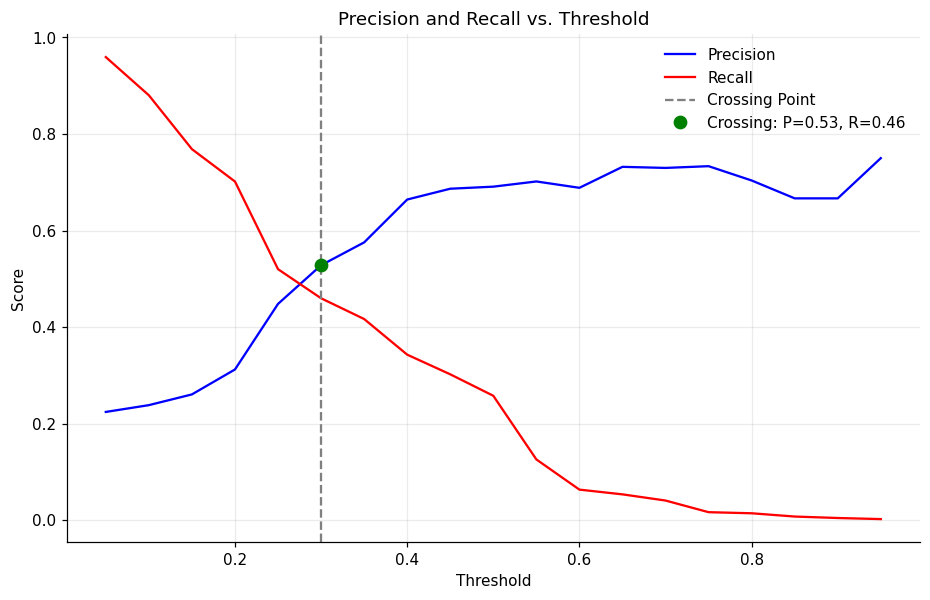

nearest crossing at threshold 0.30: precision 0.5281, recall 0.4597, 1,155 clients flagged


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the absolute difference between precision and recall
sweep['diff'] = np.abs(sweep['precision'] - sweep['recall'])

# Find the row where the absolute difference is smallest
crossing_idx = sweep['diff'].idxmin()
crossing = sweep.loc[crossing_idx].to_dict()

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep['threshold'], sweep['precision'], label='Precision', color='blue')
ax.plot(sweep['threshold'], sweep['recall'], label='Recall', color='red')

# Mark the crossing point with a vertical line
ax.axvline(crossing['threshold'], color='gray', linestyle='--', label='Crossing Point')

# Annotate the crossing point
ax.plot(crossing['threshold'], crossing['precision'], 'o', color='green', markersize=8,
        label=f"Crossing: P={crossing['precision']:.2f}, R={crossing['recall']:.2f}")

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall vs. Threshold')
ax.legend()
ax.grid(True)
plt.show()

print(f"nearest crossing at threshold {crossing['threshold']:.2f}: "
      f"precision {crossing['precision']:.4f}, recall {crossing['recall']:.4f}, "
      f"{int(crossing['n_flagged']):,} clients flagged")

### Task 2.6 — the written task

**The bank can manually review 200 applications a month.** Treat the 6,000 clients in your test set as
one month of applications.

Find the threshold that flags about 200 of them. Report what precision and recall you get there, and
then write your recommendation in the cell below. Your TA will read it and ask you about it.

There is no correct answer here. There is a justified answer and an unjustified one, and the difference
is whether you named the cost.

One more thing before you write, and it is the uncomfortable part. You are about to choose a threshold
by looking at the **test** set — the set this morning's slides said is spent **once**, at the end. That
is exactly the "fitting yourself to it" the lecture warned about, committed in three lines of code.
Do it anyway: everyone does it once, and the number is instructive. Task 3.1 is where you do it
properly and find out what the shortcut was worth.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — المهمة الكتابية

**يستطيع البنك مراجعة ٢٠٠ طلب شهريًا يدويًا.** اعتبر الـ٦٬٠٠٠ عميل في مجموعة اختبارك طلبات شهر واحد.

جِد العتبة التي تعلّم نحو مئتين منهم. واذكر الدقة والاستدعاء عندها، ثم اكتب توصيتك في الخلية التالية.
سيقرؤها مساعد التدريس ويسألك عنها.

لا توجد إجابة صحيحة هنا. توجد إجابة مبرَّرة وأخرى غير مبرَّرة، والفارق بينهما أن تذكر الثمن.

وأمر أخير قبل أن تكتب، وهو الجزء غير المريح. أنت على وشك اختيار العتبة بالنظر إلى مجموعة **الاختبار** —
وهي المجموعة التي قالت شرائح الصباح إنها تُنفَق **مرة واحدة** في النهاية. وهذا بعينه ما حذّرت منه المحاضرة
حين قالت إنك «تُلائم نفسك عليها»، وقد وقع في ثلاثة أسطر. افعلها الآن على أي حال: الجميع يقع فيها مرة،
والرقم نفسه مفيد. والمهمة ٣٫١ هي حيث تفعلها كما ينبغي وترى ثمن هذا الاختصار.

</div>

In [17]:
# ────────────────────────────────────────────────────────────────────
# 1) Search a finer grid than the sweep — steps of 0.01 — for the first threshold whose
#    flagged count drops to 200 or below.
# 2) Report precision and recall at that threshold, and how many real defaulters you catch
#    and miss in absolute numbers. Percentages hide the size of the problem.
# 3) Before you write your answer, work out what the bank's 200 reviews buy: how many of
#    the month's defaulters end up in front of a human at all.
# Search: "numpy find first index where condition true"
#
# ١) ابحث في شبكة أدقّ من المسح — بخطوة ٠٫٠١ — عن أول عتبة ينزل عندها عدد المعلَّمين إلى
#    مئتين أو أقل.
# ٢) اذكر الدقة والاستدعاء عند تلك العتبة، وكم متعثّرًا حقيقيًا تمسك وكم يفوتك بالأعداد
#    المطلقة. فالنسب المئوية تخفي حجم المشكلة.
# ٣) قبل أن تكتب إجابتك، احسب ما تشتريه مراجعات البنك المئتان: كم من متعثّر الشهر يصل إلى
#    موظف بشري أصلًا.
# ابحث عن: "numpy find first index where condition true"
# ────────────────────────────────────────────────────────────────────

REVIEW_CAPACITY = 200
# TODO: Find the threshold that flags about 200 clients, and report precision, recall, caught and missed.
# مهمة: جِد العتبة التي تعلّم نحو ٢٠٠ عميل، واذكر الدقة والاستدعاء وعدد الممسوكين والفائتين.

fine_thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

capacity_threshold = None
capacity_precision = None
capacity_recall = None
caught = None
missed = None

num_actual_defaulters = y_test.sum()

for t in fine_thresholds:
    flagged_at_t = (probs >= t)
    n_flagged = flagged_at_t.sum()

    if n_flagged <= REVIEW_CAPACITY:
        capacity_threshold = t

        true_positives = np.sum((y_test == 1) & flagged_at_t)
        false_negatives = np.sum((y_test == 1) & ~flagged_at_t)
        false_positives = np.sum((y_test == 0) & flagged_at_t)

        caught = true_positives
        missed = false_negatives

        capacity_precision = true_positives / n_flagged if n_flagged > 0 else np.nan
        capacity_recall = true_positives / num_actual_defaulters if num_actual_defaulters > 0 else np.nan
        break # Found the threshold, no need to continue

if capacity_threshold is not None:
    flagged = (probs >= capacity_threshold)
    print(f"threshold {capacity_threshold:.2f} flags {int(flagged.sum()):,} clients "
          f"(capacity is {REVIEW_CAPACITY})")
    print(f"  precision {capacity_precision:.4f} — {caught} of the {int(flagged.sum())} "
          f"reviewed really default")
    print(f"  recall    {capacity_recall:.4f} — you catch {caught} of "
          f"{int(y_test.sum()):,} defaulters, and miss {missed:,}")
else:
    print(f"Could not find a threshold that flags {REVIEW_CAPACITY} or fewer clients.")

threshold 0.57 flags 176 clients (capacity is 200)
  precision 0.6989 — 123 of the 176 reviewed really default
  recall    0.0927 — you catch 123 of 1,327 defaulters, and miss 1,204


**Your answer:** _(write three or four sentences here. Which threshold do you recommend to the bank, and
why? What does it cost — in defaults that walk past unreviewed, and in customers wrongly put in front of
a reviewer? What would you need to know about the money involved before you could do better than guess?)_

<div dir="rtl" align="right">

**إجابتك:** _(اكتب هنا ثلاث أو أربع جمل. أي عتبة توصي بها للبنك ولماذا؟ وما ثمنها — من حيث التعثّرات التي
تمرّ دون مراجعة، والعملاء الذين يوضعون أمام مراجع بلا سبب؟ وما الذي تحتاج معرفته عن المبالغ المعنيّة قبل
أن تستطيع أفضل من التخمين؟)_

</div>

## Section 3 — Stretch: choosing honestly, and reading the two curves  (≈30 min)

Open-ended, and lower expectation of completeness. Two tasks here; if time runs out, 3.2 is the one to
finish at home. This is where today's skill meets your capstone.

**Task 3.1 repairs Task 2.6.** You carve a **validation** set out of the training half, choose the
capacity threshold on that, and then spend the test set exactly once — to find out what the choice you
made on the test set was really worth.

**Task 3.2** plots the ROC curve and its AUC, then the precision-recall curve on the same predictions,
with the no-skill line marked on each. They are two views of exactly the same model, and on an
imbalanced problem they leave very different impressions.

**Link to your capstone:** whatever you build, someone will ask "how good is it?" and expect one number.
Being able to say *which* number, on *which* split, and what it hides, is the difference between a demo
and a result.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: اختيار أمين، وقراءة المنحنيين (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل. فيه مهمتان، وإن ضاق الوقت فالمهمة ٣٫٢ هي التي تُكمَل في البيت. هنا
تلتقي مهارة اليوم بمشروع تخرّجك.

**المهمة ٣٫١ تصلح المهمة ٢٫٦.** تقتطع مجموعة **تحقّق** من نصف التدريب، وتختار عتبة الطاقة الاستيعابية
عليها، ثم تُنفق مجموعة الاختبار مرة واحدة فقط — لترى كم كان يساوي الاختيار الذي بنيته على مجموعة الاختبار.

**المهمة ٣٫٢** ترسم منحنى ROC ومساحته AUC، ثم منحنى الدقة–الاستدعاء على التنبّؤات نفسها، وعلى كلٍّ منهما
خطّ «بلا مهارة». فهما رؤيتان لنموذج واحد بعينه، وفي المسائل غير المتوازنة يتركان انطباعين مختلفين جدًا.

**الصلة بمشروعك:** مهما بنيت سيسألك أحدهم «ما مدى جودته؟» متوقّعًا رقمًا واحدًا. والقدرة على تحديد **أي**
رقم، وعلى **أي** مجموعة، وما الذي يخفيه، هي الفرق بين عرض تجريبي ونتيجة.

</div>

### Task 3.1 — the split you should have had

Three sets, not two. **Training** fits the model, **validation** is what you are allowed to look at
while choosing things, and **test** is spent once, at the very end, to report a number you did not tune.

Carve a validation set out of the training half — a quarter of it, which happens to make it exactly the
same size as the test set, so the bank's 200 reviews mean the same thing on both. Refit on what is left,
choose the capacity threshold on the **validation** probabilities, and only then apply that one
threshold to the test set.

Two numbers matter at the end: the precision you would have *reported* from validation, and the
precision you actually *get* on test. The gap between them is the honest cost of choosing.

<div dir="rtl" align="right">

### المهمة ٣٫١ — التقسيم الذي كان ينبغي أن يكون

ثلاث مجموعات لا اثنتان. **التدريب** يلائم النموذج، و**التحقّق** هي ما يُسمح لك بالنظر إليه أثناء الاختيار،
و**الاختبار** تُنفق مرة واحدة في النهاية لتذكر رقمًا لم تضبطه عليه.

اقتطع مجموعة تحقّق من نصف التدريب — ربعه، وهو ما يجعلها بحجم مجموعة الاختبار نفسه، فتعني مراجعات البنك
المئتان الشيء ذاته على كلتيهما. أعد الملاءمة على ما تبقّى، واختر عتبة الطاقة الاستيعابية على احتمالات
**التحقّق**، ثم طبّق تلك العتبة وحدها على مجموعة الاختبار.

رقمان يهمّان في النهاية: الدقة التي كنت *ستذكرها* من التحقّق، والدقة التي *تحصل* عليها فعلًا على الاختبار.
والفجوة بينهما هي الثمن الأمين للاختيار.

</div>

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1) Split X_train again — test_size=0.25, stratified, random_state=42 — into a fit half
#    and a validation set. The model you fit here is a NEW model; leave the Section 2 one alone.
# 2) Choose the threshold on the VALIDATION probabilities, the same way Task 2.6 chose it:
#    the first threshold on the fine grid whose flagged count drops to the review capacity.
# 3) Then, once, score that single threshold on the test probabilities. Do not search on test.
# 4) Print validation and test side by side, and the gap in precision between them.
# Search: "sklearn train validation test three way split stratify"

X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

# Train a new Logistic Regression model
model_3_1 = LogisticRegression(max_iter=2000, random_state=42)
model_3_1.fit(X_fit, y_fit)

# Calculate probabilities for the validation set
val_probs = model_3_1.predict_proba(X_val)[:, 1]

# Find the threshold on the validation probabilities
val_capacity_threshold = None
val_n_flagged = None
val_precision = np.nan
val_recall = np.nan
val_caught = 0
val_missed = 0
num_actual_defaulters_val = y_val.sum()

for t in fine_thresholds:
    flagged_at_t_val = (val_probs >= t)
    n_flagged_val = flagged_at_t_val.sum()

    if n_flagged_val <= REVIEW_CAPACITY:
        val_capacity_threshold = t
        val_n_flagged = n_flagged_val

        val_true_positives = np.sum((y_val == 1) & flagged_at_t_val)
        val_false_negatives = np.sum((y_val == 1) & ~flagged_at_t_val)

        val_caught = val_true_positives
        val_missed = val_false_negatives

        val_precision = val_true_positives / val_n_flagged if val_n_flagged > 0 else np.nan
        val_recall = val_true_positives / num_actual_defaulters_val if num_actual_defaulters_val > 0 else np.nan
        break

# Calculate probabilities for the test set using the model_3_1
test_probs = model_3_1.predict_proba(X_test)[:, 1]

# Score the chosen threshold on the test probabilities
test_n_flagged = None
test_precision = np.nan
test_recall = np.nan
test_caught = 0
test_missed = 0

if val_capacity_threshold is not None:
    flagged_test = (test_probs >= val_capacity_threshold)
    test_n_flagged = flagged_test.sum()

    test_true_positives = np.sum((y_test == 1) & flagged_test)
    test_false_negatives = np.sum((y_test == 1) & ~flagged_test)

    test_caught = test_true_positives
    test_missed = test_false_negatives

    test_precision = test_true_positives / test_n_flagged if test_n_flagged > 0 else np.nan
    test_recall = test_true_positives / y_test.sum() if y_test.sum() > 0 else np.nan


# Print results
if val_capacity_threshold is not None:
    print(f"Capacity threshold chosen on validation: {val_capacity_threshold:.2f}")
    print(f"\nValidation set (n_flagged={val_n_flagged:,}):")
    print(f"  Precision: {val_precision:.4f} ({val_caught} of {val_n_flagged} reviewed really default)")
    print(f"  Recall:    {val_recall:.4f} (caught {val_caught} of {num_actual_defaulters_val} defaulters, missed {val_missed:,})")
    print("-" * 50)
    print(f"Test set (using the same threshold, n_flagged={test_n_flagged:,}):")
    print(f"  Precision: {test_precision:.4f} ({test_caught} of {test_n_flagged} reviewed really default)")
    print(f"  Recall:    {test_recall:.4f} (caught {test_caught} of {y_test.sum()} defaulters, missed {test_missed:,})")
    print(f"\nPrecision gap (validation - test): {val_precision - test_precision:+.4f}")
else:
    print(f"Could not find a threshold on the validation set that flags {REVIEW_CAPACITY} or fewer clients.")

Capacity threshold chosen on validation: 0.57

Validation set (n_flagged=186):
  Precision: 0.6989 (130 of 186 reviewed really default)
  Recall:    0.0980 (caught 130 of 1327 defaulters, missed 1,197)
--------------------------------------------------
Test set (using the same threshold, n_flagged=197):
  Precision: 0.6853 (135 of 197 reviewed really default)
  Recall:    0.1017 (caught 135 of 1327 defaulters, missed 1,192)

Precision gap (validation - test): +0.0136


Read the result before you decide what it means, because it is not the dramatic one.

The honest pipeline picked **0.57** — the same threshold Task 2.6 found by rummaging through the test
set. The shortcut cost you nothing this time. That happens, and it happens often on a model this simple
with a threshold this far out in the tail.

What did move is the number you would have *reported*. Validation said precision 0.6989; test delivered
0.6853. The estimate you chose on was optimistic by about one and a third points, which is exactly what
you should expect: you picked the threshold that looked best on validation, so validation flatters it.
That gap is the reason the third set exists.

So the lesson is not "the shortcut ruins your model." It is that **you were not entitled to the number**.
Had the shortcut moved the threshold by 0.10 you would have had no way of knowing, because you had spent
the only clean set you owned. The protocol is cheap and it is what lets you quote a figure to the head of
credit risk without crossing your fingers.

### Task 3.2 — two curves, and which one is honest

<div dir="rtl" align="right">

اقرأ النتيجة قبل أن تقرّر معناها، فهي ليست النتيجة المثيرة.

اختار المسار الأمين العتبة **٠٫٥٧** — وهي العتبة نفسها التي وجدتها المهمة ٢٫٦ بالتنقيب في مجموعة الاختبار.
فلم يكلّفك الاختصار شيئًا هذه المرة. وهذا يحدث كثيرًا مع نموذج بهذه البساطة وعتبة بهذا البعد في الذيل.

لكن الذي تغيّر هو الرقم الذي كنت *ستذكره*. قال التحقّق إن الدقة ٠٫٦٩٨٩، وأعطى الاختبار ٠٫٦٨٥٣. فالتقدير
الذي اخترت عليه كان متفائلًا بنحو نقطة وثلث، وهذا بالضبط ما ينبغي توقّعه: اخترت العتبة التي بدت الأفضل على
التحقّق، فجاملها التحقّق. وهذه الفجوة هي سبب وجود المجموعة الثالثة.

فالدرس ليس أن «الاختصار يفسد نموذجك»، بل أنك **لم تكن تملك حقّ ذكر الرقم**. ولو أزاح الاختصار العتبة بمقدار
٠٫١٠ لما كان لديك سبيل إلى معرفة ذلك، لأنك أنفقت المجموعة النظيفة الوحيدة التي تملكها. والإجراء رخيص، وهو
ما يتيح لك ذكر رقم لرئيس مخاطر الائتمان دون أن تعقد أصابعك.

### المهمة ٣٫٢ — منحنيان وأيّهما أمين

</div>

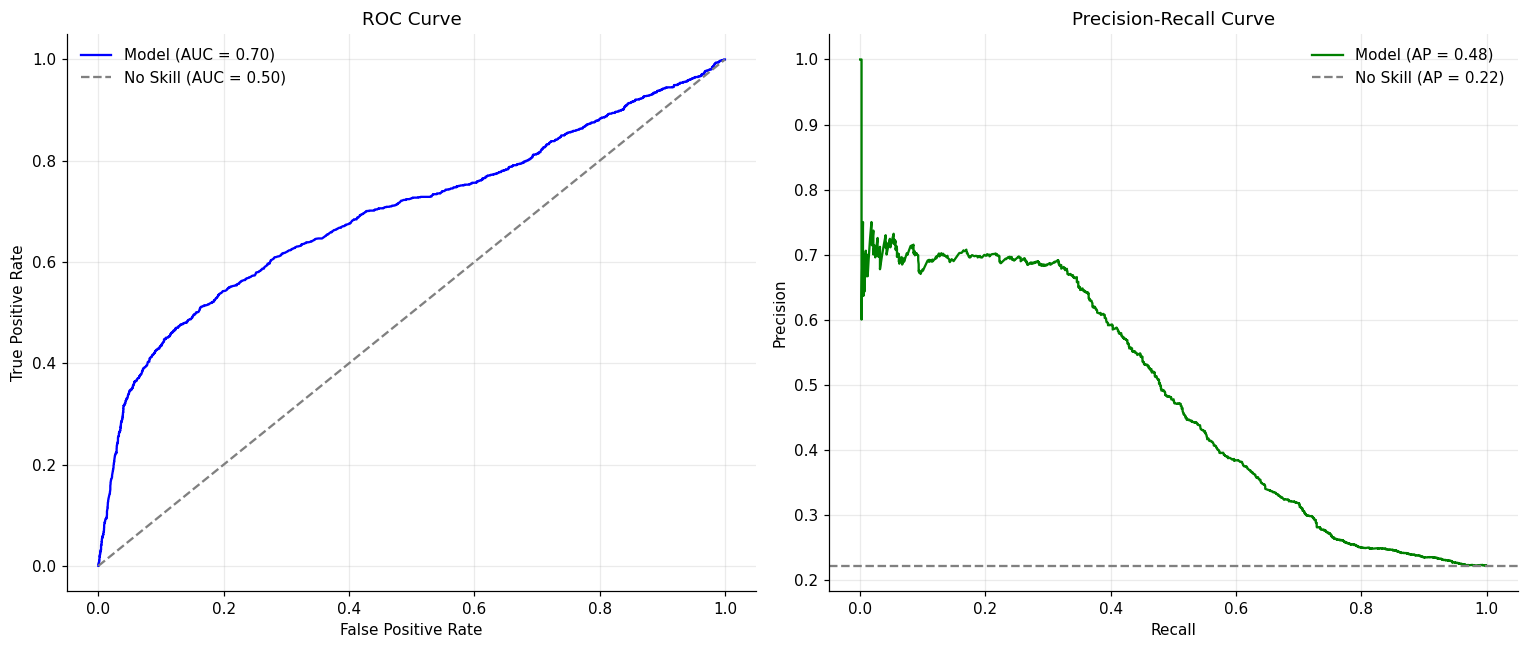

ROC AUC: 0.6971 (No skill: 0.5000)
Average Precision Score: 0.4800 (No skill: 0.2212)


In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve and Average Precision Score
pr_precision, pr_recall, _ = precision_recall_curve(y_test, probs)
avg_precision = average_precision_score(y_test, probs)

# No-skill line for ROC (diagonal)
ns_fpr, ns_tpr, _ = roc_curve(y_test, [0 for _ in range(len(y_test))]) # Predict all 0s
ns_roc_auc = auc(ns_fpr, ns_tpr)

# No-skill line for Precision-Recall (proportion of positive class)
no_skill_precision = y_test.sum() / len(y_test)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve Plot
axes[0].plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.2f})', color='blue')
axes[0].plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill (AUC = {ns_roc_auc:.2f})', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True)

# Precision-Recall Curve Plot
axes[1].plot(pr_recall, pr_precision, label=f'Model (AP = {avg_precision:.2f})', color='green')
axes[1].axhline(y=no_skill_precision, linestyle='--', label=f'No Skill (AP = {no_skill_precision:.2f})', color='gray')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f} (No skill: {ns_roc_auc:.4f})")
print(f"Average Precision Score: {avg_precision:.4f} (No skill: {no_skill_precision:.4f})")

The ROC curve looks reasonable. The AUC is 0.70 against a no-skill floor of 0.50, and if you put that on
a slide nobody would object.

The precision-recall curve tells the harder truth. It starts high and collapses: to get recall above
about 0.5 you have to drop precision below 0.45, which is to say more than half of everyone you send to
a reviewer is fine. Look at threshold 0.25 in your sweep: 1,540 clients flagged, of whom about 850 never
default. ROC hides those 850 because its x-axis is the false positive **rate**, and against 4,673
non-defaulters that is 0.18 — a small step along the curve. For precision the same 850 are the
difference between 0.69 and 0.45.

That is the rule to take away: **when the positive class is rare, the precision-recall curve is the
honest one**, because it never divides by the large, easy majority.

**Your answer:** _I'll show the precision-recall curve, because half the people I'd flag for review are actually fine, and ROC hides that since it's measured against a big, easy majority.

<div dir="rtl" align="right">

يبدو منحنى ROC معقولًا. فمساحته ٠٫٧٠ مقابل أرضية «بلا مهارة» عند ٠٫٥٠، ولو وضعتها في شريحة لما اعترض أحد.

أما منحنى الدقة–الاستدعاء فيقول الحقيقة الأصعب. يبدأ عاليًا ثم ينهار: فلرفع الاستدعاء فوق ٠٫٥ تقريبًا
عليك إنزال الدقة تحت ٠٫٤٥، أي أن أكثر من نصف من ترسلهم إلى المراجعة سليمون. انظر إلى العتبة ٠٫٢٥ في
مسحك: ١٬٥٤٠ عميلًا معلَّمًا، منهم نحو ٨٥٠ لا يتعثّرون أبدًا. ويخفي ROC هؤلاء الثمانمئة والخمسين لأن محوره
الأفقي هو **معدّل** الإيجابيات الكاذبة، ومقابل ٤٬٦٧٣ غير متعثّر يكون ٠٫١٨ — خطوة صغيرة على المنحنى. أما
في الدقة فهم الفرق بين ٠٫٦٩ و٠٫٤٥.

وهذه هي القاعدة التي تُؤخذ: **حين تكون الفئة الإيجابية نادرة يكون منحنى الدقة–الاستدعاء هو الأمين**،
لأنه لا يقسم أبدًا على الأغلبية الكبيرة السهلة.

**إجابتك:** _عرض منحنى الدقة–الاستدعاء، لأن نصف اللي بحيلهم للمراجعة أصلاً سليمين، وROC ما يبيّن هالشي لأنه يقارن بأغلبية كبيرة وسهلة تخفي المشكلة.

</div>

## Save your artefact

`threshold_sweep.parquet` is every threshold you tried and what it would have cost. W2D5 builds a full
pipeline on this same problem and compares its threshold behaviour against today's; W8's serving lab
needs a threshold baked into the API, and this file is where that number comes from.

<div dir="rtl" align="right">

## احفظ مخرجاتك

الملف `threshold_sweep.parquet` هو كل عتبة جرّبتها وما كانت ستكلّفه. ويبني الأسبوع ٢ اليوم ٥ مسارًا كاملًا
على المسألة نفسها ويقارن سلوك عتبته بعتبة اليوم؛ ويحتاج معمل النشر في الأسبوع ٨ عتبةً مثبّتة داخل الواجهة
البرمجية، ومن هذا الملف يأتي ذلك الرقم.

</div>

In [23]:
out = ARTEFACT_DIR / "threshold_sweep.parquet"
sweep.to_parquet(out, index=False)
print(f"Saved {out}  ({len(sweep)} rows)")
print(sweep.round(4).head(3).to_string(index=False))

Saved /content/artefacts/threshold_sweep.parquet  (19 rows)
 threshold  precision  recall  n_flagged   diff
      0.05     0.2242  0.9593       5677 0.7351
      0.10     0.2383  0.8802       4901 0.6419
      0.15     0.2605  0.7687       3915 0.5081


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [27]:
# --- Sanity checks ----------------------------------------------------------------
from sklearn.metrics import confusion_matrix

# Re-calculate precision and recall from Task 2.3's 0.5 threshold confusion matrix
# This ensures we use the scalar values, regardless of later variable overwrites
cm_model_05 = confusion_matrix(y_test, probs >= 0.5)
m_tn, m_fp, m_fn, m_tp = cm_model_05.ravel()

# Ensure these are the scalar values from 0.5 threshold
precision = m_tp / (m_tp + m_fp) if (m_tp + m_fp) > 0 else 0.0
recall = m_tp / (m_tp + m_fn) if (m_tp + m_fn) > 0 else 0.0

report_dict = classification_report(y_test, probs >= 0.5, output_dict=True)
sk_precision = report_dict["1"]["precision"]
sk_recall = report_dict["1"]["recall"]

check(hand_counts == {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)},
      f"your hand-counted cells must match confusion_matrix exactly: you counted {hand_counts}, "
      f"sklearn gives tp={tp} fp={fp} fn={fn} tn={tn}",
      f"يجب أن تطابق خاناتك المعدودة يدويًا مخرج confusion_matrix تمامًا: عددت {hand_counts}، "
      f"وsklearn تعطي tp={tp} fp={fp} fn={fn} tn={tn}")

check_close(precision, sk_precision,
            "your hand-computed precision should match classification_report",
            "يجب أن تطابق الدقة المحسوبة يدويًا مخرج classification_report",
            tol=1e-3)

check_close(recall, sk_recall,
            "your hand-computed recall should match classification_report",
            "يجب أن يطابق الاستدعاء المحسوب يدويًا مخرج classification_report",
            tol=1e-3)

recall_steps = sweep["recall"].to_numpy()
check(bool(np.all(np.diff(recall_steps) <= 0)),
      "recall must never rise as the threshold rises — flagging fewer clients cannot catch more "
      "defaulters. If it does, your sweep is not sorted by threshold",
      "يجب ألّا يرتفع الاستدعاء مع ارتفاع العتبة — فتعليم عملاء أقل لا يمسك متعثّرين أكثر. فإن ارتفع "
      "فمسحك غير مرتّب بحسب العتبة")

check(len(sweep) >= 15,
      f"the sweep should have at least 15 thresholds, got {len(sweep)}",
      f"يجب أن يحتوي المسح ١٥ عتبة على الأقل، والعدد {len(sweep)}")

check(abs(model_accuracy - dummy_accuracy) < 0.05,
      f"the model's accuracy ({model_accuracy:.4f}) should sit within 5 points of the dummy's "
      f"({dummy_accuracy:.4f}) — this is the point of the lab, not a bug: if the gap is large, "
      f"the feature set was widened and the lesson is gone",
      f"يجب أن تقع دقّة النموذج ({model_accuracy:.4f}) ضمن خمس نقاط من دقّة النموذج الساذج "
      f"({dummy_accuracy:.4f}) — وهذا مقصد المعمل لا خطأ فيه: فاتّساع الفارق يعني توسيع الخصائص "
      f"وضياع الدرس")

check((ARTEFACT_DIR / "threshold_sweep.parquet").exists(),
      "threshold_sweep.parquet should exist — run the save cell above",
      "يجب أن يوجد الملف threshold_sweep.parquet — شغّل خلية الحفظ أعلاه")

report()


──────────────────────────────────────────────────────────────────
  ✓  your hand-counted cells must match confusion_matrix exactly: you counted {'tp': np.int64(2), 'fp': np.int64(3), 'fn': np.int64(0), 'tn': np.int64(5)}, sklearn gives tp=2 fp=3 fn=0 tn=5
  ✓  your hand-computed precision should match classification_report (expected ≈0.6909090909090909, got 0.6909090909090909)
  ✓  your hand-computed recall should match classification_report (expected ≈0.25772418990203466, got 0.25772418990203466)
  ✓  recall must never rise as the threshold rises — flagging fewer clients cannot catch more defaulters. If it does, your sweep is not sorted by threshold
  ✓  the sweep should have at least 15 thresholds, got 19
  ✓  the model's accuracy (0.8103) should sit within 5 points of the dummy's (0.7788) — this is the point of the lab, not a bug: if the gap is large, the feature set was widened and the lesson is gone
  ✓  threshold_sweep.parquet should exist — run the save cell above
─────────────

## What's next

Tomorrow the label disappears entirely: clustering and PCA, where nothing can tell you whether you were
right and the deliverable is an argument.

<div dir="rtl" align="right">

## ماذا بعد

غدًا تختفي التسمية تمامًا: التجميع وتحليل المكوّنات الرئيسة، حيث لا شيء يخبرك هل كنت مصيبًا، ويكون
المُخرَج حجّة لا درجة.

</div>